# CSE425  — Unsupervised Neural Network for Multi-Genre Music Generation
## Steps 1 & 2: Dataset Loading + Exploratory Data Analysis

>


## 0. Install Required Libraries

In [1]:
#  Install all required libraries
!pip install pretty_midi miditok music21 --quiet

# PyTorch comes pre-installed on Colab; verify:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 33.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.6 MB/s eta 0:00:00
PyTorch version : 2.10.0+cpu
GPU available   : False



## 1. Download the MAESTRO Dataset (MIDI-only, 57 MB)



In [2]:
import os

MAESTRO_URL  = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip"
DATA_DIR     = "/content/maestro"
ZIP_PATH     = "/content/maestro-v3.0.0-midi.zip"
CSV_PATH     = os.path.join(DATA_DIR, "maestro-v3.0.0.csv")

if not os.path.exists(CSV_PATH):
    print("Downloading MAESTRO MIDI dataset (~57 MB) …")
    !wget -q --show-progress -O {ZIP_PATH} {MAESTRO_URL}
    print("Extracting …")
    !unzip -q {ZIP_PATH} -d /content/
    # The zip extracts into a folder called maestro-v3.0.0; rename for convenience
    !mv /content/maestro-v3.0.0 {DATA_DIR} 2>/dev/null || true
    print("Done!")
else:
    print("Dataset already present — skipping download.")

# Confirm structure
print("\nTop-level contents of DATA_DIR:")
print(os.listdir(DATA_DIR))

/content/maestro-v3 100%[===================>]  55.71M   232MB/s    in 0.2s    
Extracting …
Done!

Top-level contents of DATA_DIR:
['2015', '2011', '2018', '2013', 'maestro-v3.0.0.csv', 'maestro-v3.0.0.json', '2017', 'LICENSE', '2008', '2004', '2009', 'README', '2014', '2006']



## 2. Load the Metadata CSV



In [3]:
import pandas as pd

meta = pd.read_csv(CSV_PATH)

print(f"Total recordings : {len(meta)}")
print(f"Columns          : {list(meta.columns)}\n")
print("Split distribution:")
print(meta['split'].value_counts())
print(f"\nUnique composers : {meta['canonical_composer'].nunique()}")
print(f"Competition years: {sorted(meta['year'].unique())}")
meta.head()

Total recordings : 1276
Columns          : ['canonical_composer', 'canonical_title', 'split', 'year', 'midi_filename', 'audio_filename', 'duration']

Split distribution:
split
train         962
test          177
validation    137
Name: count, dtype: int64

Unique composers : 60
Competition years: [np.int64(2004), np.int64(2006), np.int64(2008), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2017), np.int64(2018)]


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


In [4]:
# ── Build absolute file paths and verify a few files exist ──────────────────
meta['filepath'] = meta['midi_filename'].apply(lambda p: os.path.join(DATA_DIR, p))

# Sanity check: all files present?
missing = meta[~meta['filepath'].apply(os.path.exists)]
print(f"Missing files: {len(missing)} / {len(meta)}")

# Preview first 3 paths
for p in meta['filepath'].head(3):
    print(p, "—", "EXISTS" if os.path.exists(p) else "MISSING")

Missing files: 0 / 1276
/content/maestro/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi — EXISTS
/content/maestro/2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MID--AUDIO_03_R2_2008_wav--2.midi — EXISTS
/content/maestro/2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-split_07-07-17_Piano-e_3-02_wav--3.midi — EXISTS



## 3. Train / Validation / Test Split



In [5]:
train_df = meta[meta['split'] == 'train'].reset_index(drop=True)
val_df   = meta[meta['split'] == 'validation'].reset_index(drop=True)
test_df  = meta[meta['split'] == 'test'].reset_index(drop=True)

print(f"Train       : {len(train_df)} recordings")
print(f"Validation  : {len(val_df)}  recordings")
print(f"Test        : {len(test_df)}  recordings")

Train       : 962 recordings
Validation  : 137  recordings
Test        : 177  recordings



## 4. Load a Single MIDI File with pretty_midi

This section shows how to access **Note objects** (pitch, velocity, start, end) from a MIDI file,  
which is the foundation for all preprocessing in Steps 3–8.

In [6]:
import pretty_midi

SAMPLE_PATH = train_df['filepath'].iloc[0]
print(f"Loading: {SAMPLE_PATH}")

pm = pretty_midi.PrettyMIDI(SAMPLE_PATH)

# MAESTRO files have a single instrument (piano)
instrument = pm.instruments[0]
notes      = instrument.notes

print(f"\nNumber of instruments : {len(pm.instruments)}")
print(f"Instrument name       : {instrument.name}  (program={instrument.program})")
print(f"Total notes in file   : {len(notes)}")
print(f"\nFirst 5 notes:")
for n in notes[:5]:
    print(f"  pitch={n.pitch:3d}  velocity={n.velocity:3d}  "
          f"start={n.start:.3f}s  end={n.end:.3f}s  "
          f"dur={n.end - n.start:.3f}s")

Loading: /content/maestro/2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi

Number of instruments : 1
Instrument name       :   (program=0)
Total notes in file   : 4197

First 5 notes:
  pitch= 67  velocity= 52  start=0.983s  end=1.810s  dur=0.827s
  pitch= 72  velocity= 67  start=1.784s  end=1.906s  dur=0.122s
  pitch= 67  velocity= 39  start=2.181s  end=3.160s  dur=0.979s
  pitch= 61  velocity= 39  start=2.178s  end=3.243s  dur=1.065s
  pitch= 78  velocity= 65  start=2.147s  end=3.600s  dur=1.453s


**Piano MIDI range:** pitch 21 (A0) → 108 (C8), covering all 88 keys.  
Middle C = pitch 60.


## 5. Step 2 — Exploratory Data Analysis (EDA)

### 5A. Piece Duration Distribution

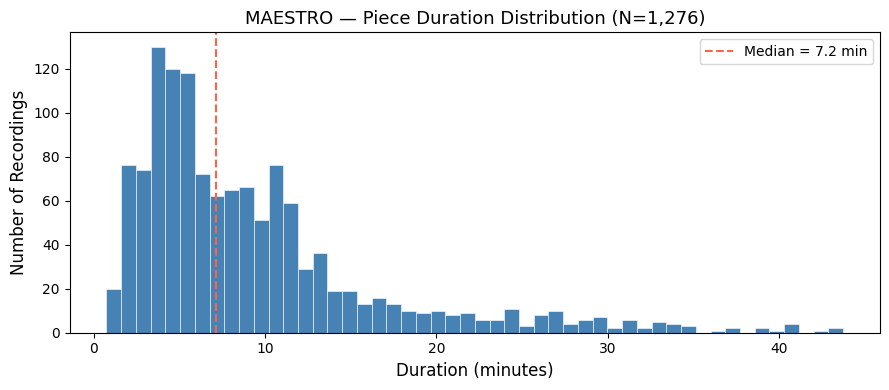

Min  : 0.75 min
Max  : 43.74 min
Mean : 9.34 min
Median:7.15 min


In [7]:
import matplotlib.pyplot as plt
import numpy as np

durations_min = meta['duration'] / 60.0   # convert seconds → minutes

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(durations_min, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(durations_min.median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Median = {durations_min.median():.1f} min")
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Recordings', fontsize=12)
ax.set_title('MAESTRO — Piece Duration Distribution (N=1,276)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('/content/plot_duration_histogram.png', dpi=150)
plt.show()

print(f"Min  : {durations_min.min():.2f} min")
print(f"Max  : {durations_min.max():.2f} min")
print(f"Mean : {durations_min.mean():.2f} min")
print(f"Median:{durations_min.median():.2f} min")

### 5B. Note Count per Piece



Loaded 100 files  |  Errors: 0


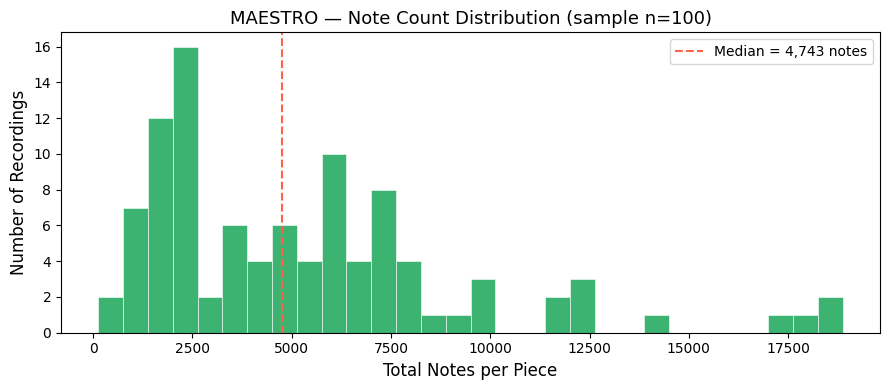


Min notes  : 129
Max notes  : 18,876
Mean notes : 5,302


In [8]:
SAMPLE_N = 100   # increase if you have time / want more accurate stats
sample_df = train_df.sample(n=SAMPLE_N, random_state=42)

note_counts = []
load_errors = []

for _, row in sample_df.iterrows():
    try:
        pm_tmp = pretty_midi.PrettyMIDI(row['filepath'])
        count  = sum(len(inst.notes) for inst in pm_tmp.instruments)
        note_counts.append(count)
    except Exception as e:
        load_errors.append(row['filepath'])

print(f"Loaded {len(note_counts)} files  |  Errors: {len(load_errors)}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(note_counts, bins=30, color='mediumseagreen', edgecolor='white', linewidth=0.4)
ax.axvline(np.median(note_counts), color='tomato', linestyle='--', linewidth=1.5,
           label=f"Median = {int(np.median(note_counts)):,} notes")
ax.set_xlabel('Total Notes per Piece', fontsize=12)
ax.set_ylabel('Number of Recordings', fontsize=12)
ax.set_title(f'MAESTRO — Note Count Distribution (sample n={SAMPLE_N})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('/content/plot_note_count_histogram.png', dpi=150)
plt.show()

print(f"\nMin notes  : {min(note_counts):,}")
print(f"Max notes  : {max(note_counts):,}")
print(f"Mean notes : {int(np.mean(note_counts)):,}")

### 5C. Pitch Distribution



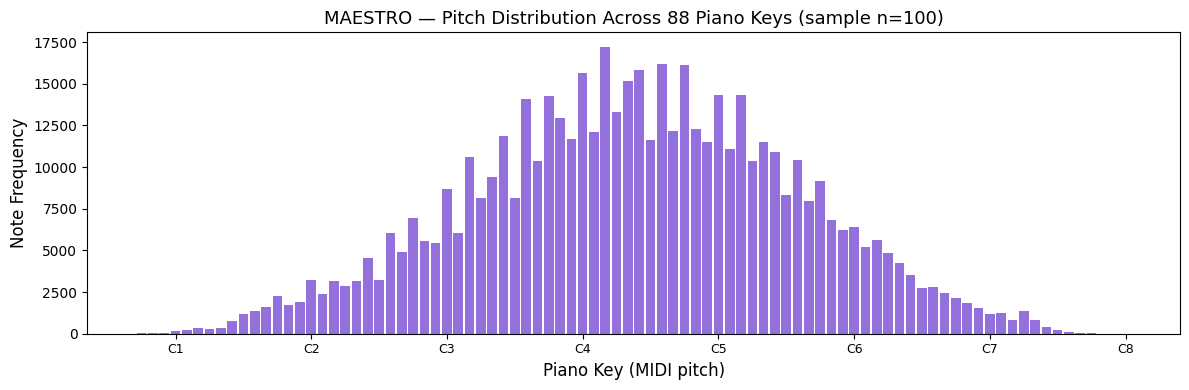

Most frequently played pitch: MIDI 62  (D4)


In [9]:
pitch_counts = np.zeros(128, dtype=np.int64)

for _, row in sample_df.iterrows():
    try:
        pm_tmp = pretty_midi.PrettyMIDI(row['filepath'])
        for inst in pm_tmp.instruments:
            for note in inst.notes:
                pitch_counts[note.pitch] += 1
    except:
        pass

# Piano range: MIDI 21 (A0) to 108 (C8)
piano_pitches = np.arange(21, 109)
piano_counts  = pitch_counts[21:109]

# Build readable x-axis labels every 12 semitones
note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
xtick_pos, xtick_lbl = [], []
for p in piano_pitches:
    if p % 12 == 0:          # C notes
        octave = (p // 12) - 1
        xtick_pos.append(p - 21)
        xtick_lbl.append(f"C{octave}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(88), piano_counts, color='mediumpurple', width=0.85)
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lbl, fontsize=9)
ax.set_xlabel('Piano Key (MIDI pitch)', fontsize=12)
ax.set_ylabel('Note Frequency', fontsize=12)
ax.set_title(f'MAESTRO — Pitch Distribution Across 88 Piano Keys (sample n={SAMPLE_N})', fontsize=13)
plt.tight_layout()
plt.savefig('/content/plot_pitch_distribution.png', dpi=150)
plt.show()

most_common_midi = piano_pitches[np.argmax(piano_counts)]
note_name = note_names[most_common_midi % 12]
octave    = (most_common_midi // 12) - 1
print(f"Most frequently played pitch: MIDI {most_common_midi}  ({note_name}{octave})")

### 5D. Velocity Distribution

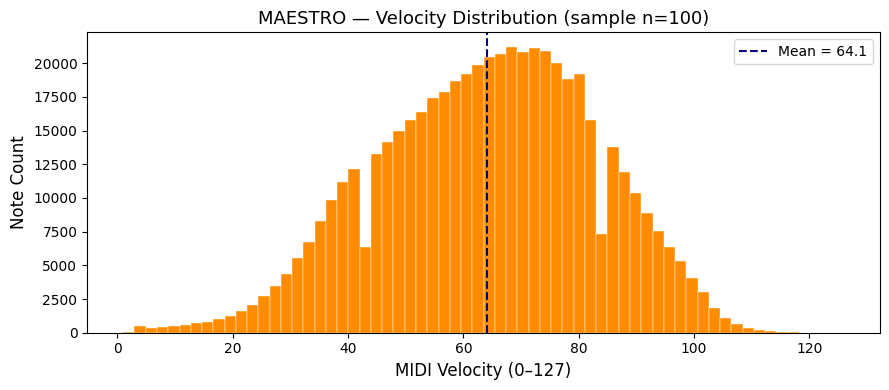

Velocity range : 1 – 126
Mean velocity  : 64.1
Std deviation  : 18.8


In [10]:
all_velocities = []

for _, row in sample_df.iterrows():
    try:
        pm_tmp = pretty_midi.PrettyMIDI(row['filepath'])
        for inst in pm_tmp.instruments:
            for note in inst.notes:
                all_velocities.append(note.velocity)
    except:
        pass

all_velocities = np.array(all_velocities)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_velocities, bins=64, color='darkorange', edgecolor='white', linewidth=0.3)
ax.axvline(np.mean(all_velocities), color='navy', linestyle='--', linewidth=1.5,
           label=f"Mean = {np.mean(all_velocities):.1f}")
ax.set_xlabel('MIDI Velocity (0–127)', fontsize=12)
ax.set_ylabel('Note Count', fontsize=12)
ax.set_title(f'MAESTRO — Velocity Distribution (sample n={SAMPLE_N})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('/content/plot_velocity_distribution.png', dpi=150)
plt.show()

print(f"Velocity range : {all_velocities.min()} – {all_velocities.max()}")
print(f"Mean velocity  : {np.mean(all_velocities):.1f}")
print(f"Std deviation  : {np.std(all_velocities):.1f}")

### 5E. Piano-Roll Sparsity Check



In [11]:
FS = 16   # frames per second (used throughout Tasks 1 & 2)

sparsity_results = []

for i, (_, row) in enumerate(train_df.sample(3, random_state=7).iterrows()):
    try:
        pm_tmp    = pretty_midi.PrettyMIDI(row['filepath'])
        # get_piano_roll returns shape (128, T)
        roll      = pm_tmp.get_piano_roll(fs=FS)
        # Restrict to piano range: rows 21–108 → shape (88, T)
        roll      = roll[21:109, :]
        total     = roll.size
        active    = np.count_nonzero(roll)
        sparsity  = 1.0 - active / total
        sparsity_results.append(sparsity)
        title_short = row['canonical_title'][:40]
        print(f"File {i+1}: {row['canonical_composer'][:25]:25s}  "
              f"shape={roll.shape}  "
              f"active={active:,}  sparsity={sparsity*100:.2f}%")
    except Exception as e:
        print(f"Error: {e}")

print(f"\nAverage sparsity : {np.mean(sparsity_results)*100:.2f}%")
print("\n→ ~97-98% of cells are zero. Plain MSE will collapse to predicting silence.")
print("→ Use Focal Loss or BCEWithLogitsLoss with pos_weight to compensate.")

File 1: Franz Schubert             shape=(88, 35371)  active=150,180  sparsity=95.18%
File 2: Franz Schubert             shape=(88, 8318)  active=32,587  sparsity=95.55%
File 3: Antonio Soler              shape=(88, 3723)  active=4,978  sparsity=98.48%

Average sparsity : 96.40%

→ ~97-98% of cells are zero. Plain MSE will collapse to predicting silence.
→ Use Focal Loss or BCEWithLogitsLoss with pos_weight to compensate.


### 5F. Visualise a Piano-Roll

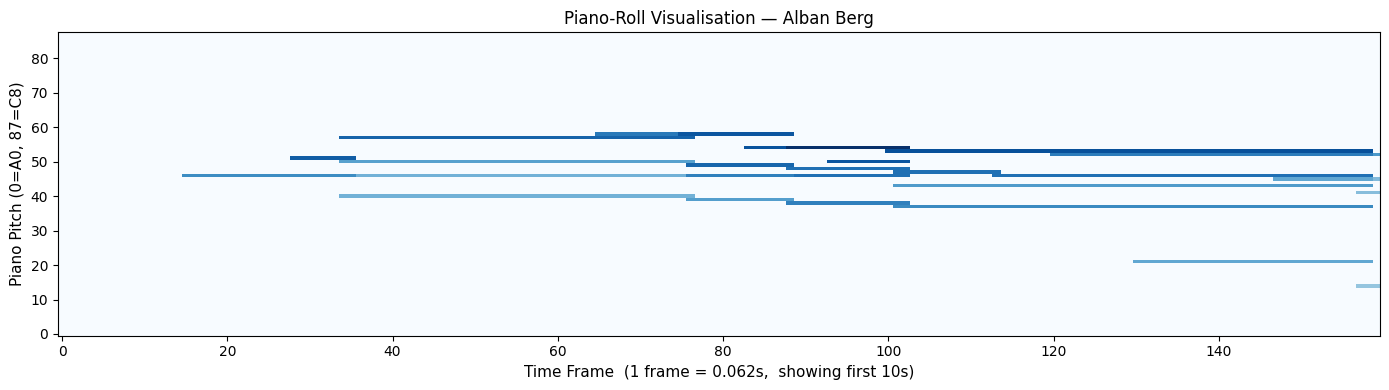

In [12]:
pm_viz  = pretty_midi.PrettyMIDI(train_df['filepath'].iloc[0])
roll_viz = pm_viz.get_piano_roll(fs=FS)[21:109, :]   # shape (88, T)

# Show first 10 seconds = first 160 frames
SHOW_FRAMES = 160

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(roll_viz[:, :SHOW_FRAMES], aspect='auto', origin='lower',
          cmap='Blues', interpolation='nearest')
ax.set_xlabel(f'Time Frame  (1 frame = {1/FS:.3f}s,  showing first {SHOW_FRAMES/FS:.0f}s)', fontsize=11)
ax.set_ylabel('Piano Pitch (0=A0, 87=C8)', fontsize=11)
ax.set_title(f'Piano-Roll Visualisation — {train_df["canonical_composer"].iloc[0]}', fontsize=12)
plt.tight_layout()
plt.savefig('/content/plot_piano_roll_sample.png', dpi=150)
plt.show()